# **Previsão de intenção de compras em um site de e-commerce**

## **Objetivo do projeto**

#### desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indiquem uma propensão deles a realizar compras no site da empresa. 

#### o modelo pretende auxiliar no aprimoramento da experiência do cliente, permitindo que o negócio direcione seus esforços de marketing de forma mais eficiente.

## **Entendimento da base de dados**

#### o dataset contém informações detalhadas sobre os clientes, incluindo:

#### dados demográficos (idade, renda, etc.)

#### e informações sobre compras anteriores.


#### **variáveis:**

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto.

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.

**WebPurchases: Número de compras feitas pelo site da empresa.**

## **Importação das bibliotecas**

In [1]:
# bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# bibliotecas para modelos de Machine Learning
from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV,
    learning_curve    
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import(
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import(
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv('../BASE DE DADOS/marketing_campaign.csv', delimiter= ';')

df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13)

In [4]:
# linhas nulas
df[df.isnull().any(axis=1)].head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
10,1983,Graduation,Married,NaN,1,11,5,5,6,0,2,1,2,7,0,0
27,1986,Graduation,Single,NaN,1,19,5,1,3,3,263,362,0,1,0,1
43,1959,PhD,Single,NaN,0,80,81,11,50,3,2,39,4,2,0,0
48,1951,Graduation,Single,NaN,2,96,48,5,48,6,10,7,4,6,0,0
58,1982,Graduation,Single,NaN,1,57,11,3,22,2,2,6,3,6,0,0


In [5]:
print('Número de valores nulos na variável income:')
df['Income'].isnull().sum()

Número de valores nulos na variável income:


np.int64(24)

In [6]:
# linhas duplicadas
df[df.duplicated(keep=False)].sort_values(list(df.columns))

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
39,1943,PhD,Divorced,48948.0,0,53,437,8,206,160,49,42,5,6,0,1
894,1943,PhD,Divorced,48948.0,0,53,437,8,206,160,49,42,5,6,0,1
17,1946,Graduation,Together,37760.0,0,20,84,5,38,150,12,28,6,7,0,1
282,1946,Graduation,Together,37760.0,0,20,84,5,38,150,12,28,6,7,0,1
182,1946,Master,Married,66835.0,0,21,620,26,195,34,17,141,13,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1578,1992,Graduation,Married,34935.0,0,71,34,4,66,3,10,20,4,7,0,0
392,1993,Graduation,Single,74293.0,0,66,375,152,335,93,91,81,6,2,0,1
928,1993,Graduation,Single,74293.0,0,66,375,152,335,93,91,81,6,2,0,1
696,1995,Graduation,Single,34824.0,0,65,4,2,11,2,0,4,2,6,0,0


In [7]:
print('Número de valores duplicados:')
df.duplicated().sum()

Número de valores duplicados:


np.int64(201)

In [8]:
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,5.790179,5.316518,0.009375,0.503571
std,11.984069,25173.076661,0.538398,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,3.250958,2.426645,0.096391,0.500099
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


## **Entendendo a base de dados**

#### o dataset possui **2.240 registros e 16 variáveis** sendo:

#### 2 categóricas ('Education' e 'Marital_Status') e as demais numéricas.

#### A variável 'Income' apresenta **24 valores ausentes.**

#### há **201 registros duplicados** encontrados que serão tratados caso indiquem redundância para evitar viés na modelagem.

#### há uma alta variabilidade nos dados e possíveis outliers, principalmente nas variáveis de comportamento de compras, o que é esperado que alguns clientes consumam mais produtos que outros, 

#### apresentando alguns valores extremos que serão tratados caso indiquem erro de coleta.

## **Tratamento de valores nulos** 

#### como valores nulos na variável 'income' representam ~1% da base, realizou-se a **imputação pela mediana,** pois é uma estratégia mais robusta que a medida estatística média nesse cenário com valores extremos.

In [9]:
df['Income'] = df['Income'].fillna(df['Income'].median())

## **Tratamento de duplicatas**

#### há ~8,9% registros duplicados na base e como não representam clientes diferentes, isso pode prejudicar o modelo, distorcendo a análise e gerando viés estatístico.

#### serão removidas, portanto, todas as duplicatas, mantendo apenas a primeira ocorrência.

In [10]:
df = df.drop_duplicates()

## **Análise e tratamento de outliers**

In [11]:
df[df['Income'] > 200000]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
2233,1977,Graduation,Together,666666.0,1,23,9,14,18,8,1,12,3,6,0,0


#### Apenas um registro com renda acima de 200.000, significativamente superior a distribuição geral do dataset. Isso indica fortemente erro de registro, pois não representa um grupo real de clientes.

#### Dessa forma, será feita a remoção desse registro pois pode distorcer a análise e modelagem.

In [12]:
# removendo a linha com outlier
df = df.drop(index=2233)

## **Validação**

In [13]:
print('Número de valores nulos após a limpeza:')
print(df['Income'].isnull().sum())
print('\nNúmero de duplicatas após a limpeza:')
print(df.duplicated().sum())
print('\nValor máximo da variável Income:')
print(df['Income'].max())

Número de valores nulos após a limpeza:
0

Número de duplicatas após a limpeza:
0

Valor máximo da variável Income:
162397.0


In [14]:
df.shape

(2038, 16)

#### O dataset pós-limpeza possui **2038 registros e 16 variáveis**

In [ ]:
# salvando base processada
df.to_csv(r"E:\MAYLSON - CIENCIAS DE DADOS\Ciencia de Dados\PREVISÃO DE INTENÇÃO DE COMPRA\BASE DE DADOS\processada\mkt_processed.csv", index=False)

# **Análise exploratória**

## **Distribuição da variável-alvo**

In [15]:
df['WebPurchases'].value_counts()

WebPurchases
1    1030
0    1008
Name: count, dtype: int64

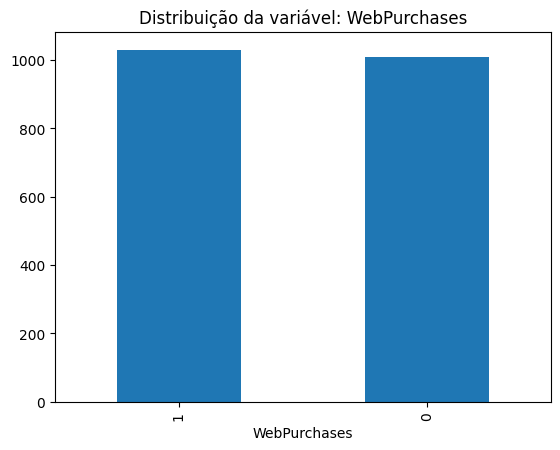

In [16]:
df['WebPurchases'].value_counts().plot(kind='bar')

plt.title('Distribuição da variável: WebPurchases')
plt.show()

#### com 1030 registros de indivíduos que compraram e 1008 que não compraram, a variável-alvo não é considerada desbalanceada, pois estão divididas praticamente em 50/50 

#### isso indica que para etapa de modelagem, não são necessárias técnicas de balanceamento.

## **Matriz de correlação linear**

In [17]:
corr = df.corr(numeric_only=True)

# relacionando com a variável target
corr['WebPurchases'].sort_values(ascending=False)

WebPurchases         1.000000
MntWines             0.543291
NumStorePurchases    0.537668
Income               0.513992
MntGoldProds         0.388735
MntMeatProducts      0.377212
MntSweetProducts     0.365955
MntFruits            0.345096
MntFishProducts      0.330011
Recency             -0.005309
Complain            -0.030942
Year_Birth          -0.147347
NumWebVisitsMonth   -0.149081
Kidhome             -0.410468
Name: WebPurchases, dtype: float64

#### As variáveis com maior correlação positiva com a Target, são:

**'MntWines', variável comportamental forte,** que indica que clientes que apresentam maior gasto com vinho tendem a apresentar maior probabilidade de realizar compras online.

**'NumStorePurchases', variável comportamental forte,** mostra que indivíduos que frequentam a loja física estão mais propensos a comprar online (Omnichannel)

e **'Income', variável econômica relevante,** indica que clientes com maior renda apresentam maior probabilidade de compra online, possivelmente devido ao maior poder de consumo.

#### a base também trás variáveis que possuem correlação negativa com a target, especialmente:

**'Kidhome', variável demográfica com efeito negativo,** sugerindo que indivíduos com menos crianças em casa estão mais propensos a comprar.

#### essas variáveis demonstram forte associação com a variável target e podem representar bons candidatos para o modelo preditivo.

Text(0.5, 1.0, 'Matriz de correlação linear')

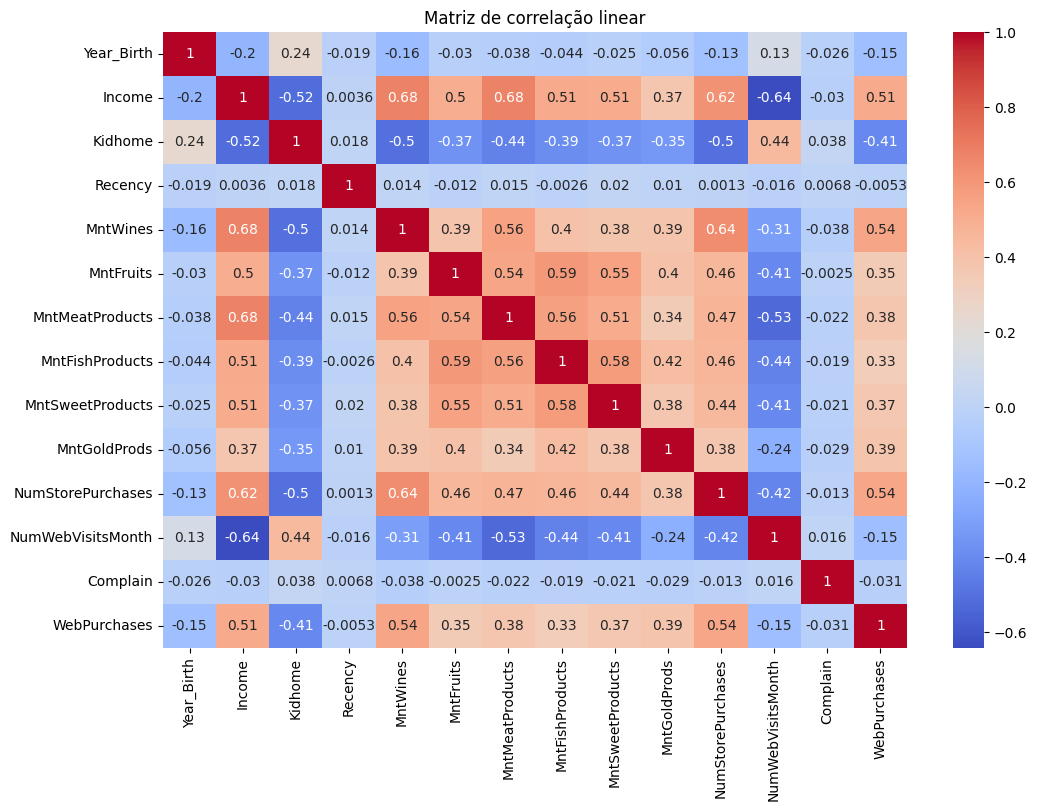

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True
)

plt.title("Matriz de correlação linear")

#### Algumas variáveis possuem alta correlação entre si, como:

**'MntWines' e 'NumStorePurchases'**, variável comportamental forte, indicando que clientes com maior gasto em vinhos também tendem a apresentar maior frequência de compras em loja física.

**'Income' com 'MntMeatProducts' e 'MntWines'**, indica que indivíduos com maior renda também gastam mais com vinhos e carnes.

**Kidhome com 'NumStorePurchases' e 'MntWines',** mostra correlação negativa, indicando que clientes com mais crianças em casa gastam menos com vinho e compram menos na loja física.

**Income e NumWebVisitsMonth** mostra correlação negativa moderada, indicando que quanto maior a renda, menos visitas no site.

#### a base apresenta multicolinearidade, que podem trazer redundância de informação em modelos lineares, por exemplo. 

#### Dessa forma, serão avaliadas estratégias de engenharia de variáveis e/ou redução de dimensionalidade com o objetivo de simplificar o modelo e melhorar sua interpretabilidade.

## **Análise descritiva**

nessa etapa busca-se entender melhor a distribuição das variáveis que apresentaram maior desvio padrão: **Income, MntWines e MntMeatProducts**

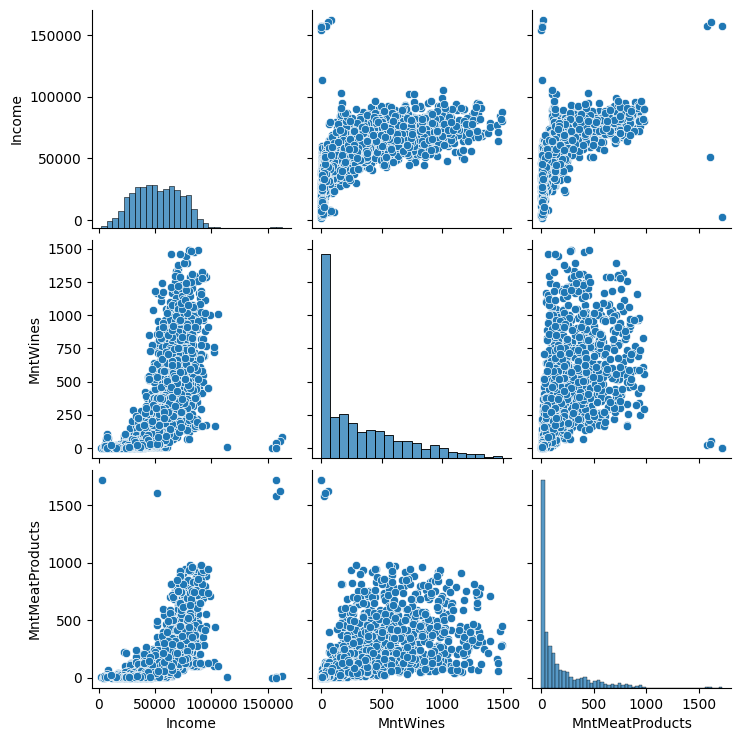

In [19]:
sns.pairplot(df[['Income', 'MntWines', 'MntMeatProducts']])

plt.show()

## **Conclusões da análise descritiva**

#### realizou-se uma investigação de outliers nas variáveis que apresentaram maior desvio padrão do dataset, que são variáveis relacionadas a renda e histórico de gastos dos clientes.

#### Observou-se a presença de valores extremos em algumas categorias, comportamento esperado em bases de consumo, onde determinados clientes podem apresentar níveis significativamente mais elevados de gasto em comparação com a 

#### média da população. Dessa forma, esses valores foram mantidos por representarem comportamentos reais de clientes com alto volume de compras, sendo relevantes para o entendimento do padrão de consumo.

## **Feature Engennering**

#### aqui será realizada a agregação das variáveis de consumo, trazendo o total gasto, com isso busca-se descobrir padrões fortes de comportamento.

#### também será transformada a variável 'year_Birth' em 'age', pois idade é mais interpretável para o modelo.

In [20]:
df['Age'] = 2025 - df['Year_Birth']

df = df.drop(columns= 'Year_Birth')

<Axes: xlabel='WebPurchases', ylabel='Total_Spending'>

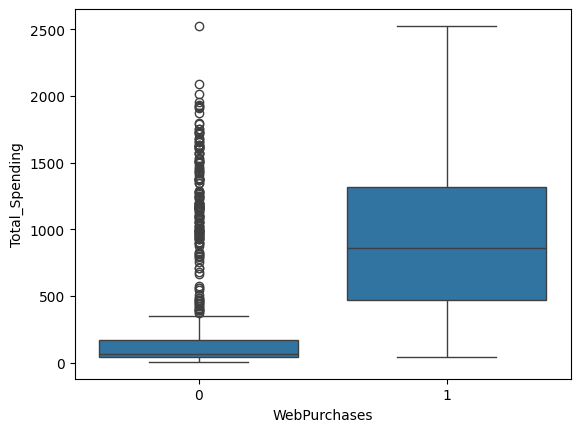

In [21]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# Gráfico de caixa
sns.boxplot(
    x='WebPurchases',
    y='Total_Spending',
    data=df
)


#### com a distribuição da variável-alvo, é possível perceber uma diferença clara nos gastos entre quem compra e quem não compra, embora muitos indivíduos que não compram online, apresentam sim muitos gastos.

## **Conclusões iniciais**

#### A variável target apresenta distribuição praticamente equilibrada entre as classes, indicando ausência de problemas relevantes de desbalanceamento que poderiam prejudicar o treinamento dos modelos preditivos.

#### A análise de correlação revelou associações relevantes entre variáveis comportamentais e a variável alvo, sugerindo bons candidatos para a etapa de modelagem.

#### Observou-se também a presença de multicolinearidade entre algumas variáveis relacionadas ao consumo de produtos. 

#### Esse comportamento é esperado em dados de consumo, uma vez que clientes que apresentam maior volume de gastos tendem a consumir diferentes categorias de produtos. 

#### Embora essa característica possa gerar redundância em modelos lineares, modelos baseados em árvore tendem a lidar melhor com esse tipo de relação.

#### Durante a etapa de limpeza foi identificado um valor extremo na variável Income, significativamente distante da distribuição observada na base. Esse registro foi removido por indicar possível inconsistência de coleta. 

#### Por outro lado, valores elevados nas variáveis de consumo foram mantidos por representarem comportamentos reais de clientes com alto volume de compras.

#### Foi realizada por fim a inclusão de uma variável comportamental que trás o consumo total dos clientes no intuito de enriquecer o modelo com informações relevantes.

## **Validação pós-EDA**

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2038 entries, 0 to 2239
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Education          2038 non-null   object 
 1   Marital_Status     2038 non-null   object 
 2   Income             2038 non-null   float64
 3   Kidhome            2038 non-null   int64  
 4   Recency            2038 non-null   int64  
 5   MntWines           2038 non-null   int64  
 6   MntFruits          2038 non-null   int64  
 7   MntMeatProducts    2038 non-null   int64  
 8   MntFishProducts    2038 non-null   int64  
 9   MntSweetProducts   2038 non-null   int64  
 10  MntGoldProds       2038 non-null   int64  
 11  NumStorePurchases  2038 non-null   int64  
 12  NumWebVisitsMonth  2038 non-null   int64  
 13  Complain           2038 non-null   int64  
 14  WebPurchases       2038 non-null   int64  
 15  Age                2038 non-null   int64  
 16  Total_Spending     2038 non-n

#### com base nos insights obtidos durante a análise exploratória, não há necessidade de reduzir dimensionalidade, pois a base só possui 17 variáveis.

#### Além disso, técnicas como PCA (análise dos componentes principais) trás perda de interpretabilidade de negócio, pois as variáveis viram combinações matemáticas das variáveis originais.

#### Como se pretende nesse projeto testar modelos baseados em árvores que lidam bem com multicolinearidade, PCA não traria vantagem real.

#### O próximo passo do projeto consiste na preparação dos dados para modelagem, incluindo codificação de variáveis categóricas, 

#### separação entre conjuntos de treino e teste e construção dos primeiros modelos preditivos.

# **Pré-modelagem**

## **Tratamento das variáveis categóricas**

#### nessa etapa será analisada a distribuição das variáveis categóricas e se precisam de algum tratamento antes da codificação.

In [23]:
df['Marital_Status'].value_counts()

Marital_Status
Married     788
Together    516
Single      445
Divorced    213
Widow        70
Alone         3
Absurd        2
YOLO          1
Name: count, dtype: int64

#### as três menores classes: **'Alone', 'Absurd' e 'YOLO'** parecem problemáticas, pois não se traduzem muito bem, além de possuirem pouquíssimos registros, **6 no total** 

#### mantendo-as o modelo cria mais colunas irrisórias, gerando features inúteis, ruído estatistico e risco de overfitting.

#### optou-se por substitui-los por **'Single'**, agrupando-os na classe já existente, pois são poucos dados e assim não gera nenhum viés.

In [24]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})

## **Validação**

In [25]:
df['Marital_Status'].value_counts()

Marital_Status
Married     788
Together    516
Single      451
Divorced    213
Widow        70
Name: count, dtype: int64

#### A variável 'Single' passa de **445 para 451 registros** após a substituição.

#### A variável 'Education' não apresentou nenhuma anormalidade, sendo codificada sem tratamentos.

In [26]:
df['Education'].value_counts()

Education
Graduation    1024
PhD            442
Master         337
2n Cycle       186
Basic           49
Name: count, dtype: int64

## **Codificação das variáveis categóricas**

In [27]:
df = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    drop_first=True,     # ajuda a evitar problemas ligados a multicolinearidade
    dtype=int
)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2038 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2038 non-null   float64
 1   Kidhome                  2038 non-null   int64  
 2   Recency                  2038 non-null   int64  
 3   MntWines                 2038 non-null   int64  
 4   MntFruits                2038 non-null   int64  
 5   MntMeatProducts          2038 non-null   int64  
 6   MntFishProducts          2038 non-null   int64  
 7   MntSweetProducts         2038 non-null   int64  
 8   MntGoldProds             2038 non-null   int64  
 9   NumStorePurchases        2038 non-null   int64  
 10  NumWebVisitsMonth        2038 non-null   int64  
 11  Complain                 2038 non-null   int64  
 12  WebPurchases             2038 non-null   int64  
 13  Age                      2038 non-null   int64  
 14  Total_Spending           2038

## **Separação da base em treino e teste**

#### nessa etapa, dividiremos a base antes de qualquer transformação a fim de evitar qualquer vazamento de informações.

In [28]:
# base com todas as variáveis, sem a variável target
X = df.drop(columns='WebPurchases')

# base com a variável target
y = df['WebPurchases']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## **Escalonamento das variáveis**

#### como o modelo baseline escolhido foi **LogisticRegression**, será feita a técnica de padronização das variáveis para garantir eficiência no modelo.

In [30]:
scaler = StandardScaler()

# fit somente no treino
X_train_scaled = scaler.fit_transform(X_train)

# **Modelagem**

## **Treinamento do modelo baseline com Cross-validation**

#### A variável Total_Spending foi criada para capturar o comportamento geral de consumo dos clientes. Apesar de apresentar redundância com as variáveis individuais de gasto (Mnt...), 

#### ela foi mantida no modelo para avaliar se a agregação dessas informações melhora o poder preditivo. Posteriormente, será testado um modelo sem essa redundância para comparar performances.

In [31]:
model = LogisticRegression(max_iter=1000)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_lr = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print('Acurácia em cada fold:')
print(scores_lr)
print('\nAcurácia média do modelo:')
print("Lr Média:", scores_lr.mean())

Acurácia em cada fold:
[0.84662577 0.82822086 0.85582822 0.85582822 0.8190184 ]

Acurácia média do modelo:
Lr Média: 0.8411042944785277


#### O modelo possui boa performance, 84% de acurácia, indica que os padrões da base são relativamente claros e que as features possuem informação útil para prever a compra.

#### O modelo é estável e com variação pequena e não parece haver overfitting.

#### Na estapa seguinte será avaliado outro cenário de modelagem: removendo a variável agregada para reduzir redundância de informação.

#### Essa comparação entre os modelos permitirá avaliar o impacto da multicolinearidade no desempenho preditivo.

## **Treinamento sem a variável agregada**

In [32]:
# removendo variável 'Total_Spending'
X_train_no_total = X_train.drop(columns='Total_Spending')

# escalonando novamente
scaler = StandardScaler()

X_train_no_total_scaled = scaler.fit_transform(X_train_no_total)

# instanciando o modelo
model = LogisticRegression(max_iter=1000)

# configurando cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# rodando a validação cruzada
scores_lr_no_total = cross_val_score(
    model,
    X_train_no_total_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print('Acurácia em cada fold')
print(scores_lr_no_total)
print('\nAcurácia média do modelo')
print("LR sem Total_Spending média:", scores_lr_no_total.mean())

Acurácia em cada fold
[0.83128834 0.85276074 0.83128834 0.83128834 0.84969325]

Acurácia média do modelo
LR sem Total_Spending média: 0.8392638036809815


#### com uma diferença estatística irrelevante na prática, a variável 'Total_spending' não trouxe ganho relevante para o modelo, pois ele já consegue inferir essa informação a partir das variáveis individuais.

#### Dessa forma, optou-se por remover Total_Spending e manter apenas as variáveis individuais de gasto, simplificando o modelo e reduzindo possíveis efeitos de multicolinearidade.

## **Remoção da variável agregada**

In [33]:
X_train = X_train.drop(columns='Total_Spending')
X_test = X_test.drop(columns='Total_Spending')

## **Treinamento do modelo Random Forest Classifier com Cross validation**

In [34]:
# modelo
rf_model = RandomForestClassifier(random_state=42)

# configuração da validação cruzada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# validação cruzada
scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Acurácia em cada fold:")
print(scores_rf)

print("\nRandom Forest média:", scores_rf.mean())

Acurácia em cada fold:
[0.90490798 0.89877301 0.89877301 0.87730061 0.90184049]

Random Forest média: 0.8963190184049079


## **Comparação de modelos**

#### Com mais de 5.7 pontos percentuais, o escolhido nesse projeto foi o modelo Random Forest Classifier, pois trouxe um ganho significativo de desempenho em relação ao baseline, **com acurácia de 89%,** 

#### pois ele consegue lidar melhor com relações não lineares e interações entre as variáveis cmoportamentais de clientes, alem de threshold naturais.

## **Ajuste de hiperparâmetros**

#### aqui será usada a técnica de Randomized search CV para tuning do modelo, pois o dataset é médio, muitos parâmetros e é uma técnica mais rápida que o Grid Search CV.

In [35]:
# busca por melhores parâmetros
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# instanciando o modelo
rf = RandomForestClassifier(random_state=42)

# aplicando a técnica
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print('Melhores parâmetros:\n')
print(best_rf)

Melhores parâmetros:

RandomForestClassifier(max_depth=20, max_features='log2', n_estimators=200,
                       random_state=42)


#### seguindo as indicações da técnica do Randomized search CV que trouxe um resultado bem coerente e saudável, o modelo final Random Forest Classifier será treinado e testado com os seguintes ajustes:

#### **max_depth-** o máximo de profundiade das árvores será 20, indicando que captura padrões complexos.

#### **max_features -** o máximo de recursos (variáveis) selecionados serão 4 ou 5 features em cada split, pois log2 do total de 23 colunas, é aproximadamente 4.52. Esse número de variáveis reduz correlação entre árvores.

#### **n_estimators -** o número de árvores na floresta randômica será 200, bom equilíbrio de performance vs custo

## **Treinamento final do Random forest**

#### nessa etapa será treinado o modelo com todo o conjunto de treino, pois antes usou-se folds apenas para validação.

#### nesse novo treino o modelo está ajustado com os melhores parâmetros e pronto para simular produção.

In [36]:
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## **Teste final do Random Forest**

#### somente nessa etapa serão usadas as bases de teste nesse projeto.

In [37]:
# previsão
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:,1]

## **Avaliação do modelo**

In [38]:
# métricas 
print("Acurácia:", accuracy_score(y_test, y_pred))

print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.9044117647058824

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.92      0.89      0.90       202
           1       0.89      0.92      0.91       206

    accuracy                           0.90       408
   macro avg       0.90      0.90      0.90       408
weighted avg       0.90      0.90      0.90       408



#### O modelo permaneceu estável, com 89% de acurácia no treino e 90% no teste final, portanto, sem apresentar overfitting.

#### e F1-score (unindo precision e recall) de 91% na classe positiva, indicando boa previsão dos clientes que compram.

## **Matriz de confusão**

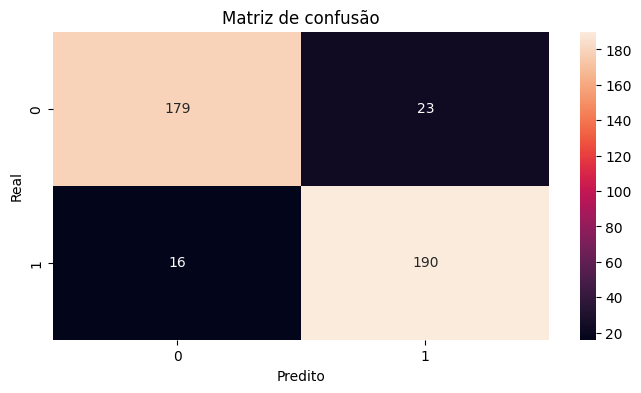

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de confusão')

plt.show()

#### detalhando as previsões, percebe-se que o modelo apresenta bom desempenho na identificação de ambas as classes:

#### dos 202 registros na classe 0 (não compradores),

#### o modelo acertou ~89% (179 verdadeiros negativos), indicando boa capacidade de evitar falsos positivos.

#### e dos 206 registros na classe 1 (compradores),

#### o modelo acertou ~92% (190 verdadeiros positivos), demonstrando alta eficiência na identificação de clientes com potencial de compra.

#### a taxa de falsos negativos, decisão mais crítica do modelo, pois indicam indivíduos compradores que o modelo os classificou como não compradores, ficou em ~7,8%,

#### esse tipo de erro é especialmente crítico em cenários de negócio, pois pode representar perda de oportunidades de venda e impacto direto na receita.

#### por outro lado, os falsos positivos (23 casos) indicam clientes classificados como compradores que não compraram, o que pode gerar custos adicionais em campanhas de marketing direcionadas.

#### Dessa forma, o modelo apresenta um bom equilíbrio entre identificação de clientes compradores e controle de custos operacionais.

#### Dependendo da estratégia de negócio, pode ser interessante ajustar o threshold de decisão do modelo para reduzir ainda mais os falsos negativos,

#### mesmo que isso aumente levemente os falsos positivos.

## **Curva AUC-ROC**

#### Nessa avaliação se mede a capacidade de separação das classes, onde quanto mais perto de 1, melhor.


ROC AUC: 0.9636523118331252


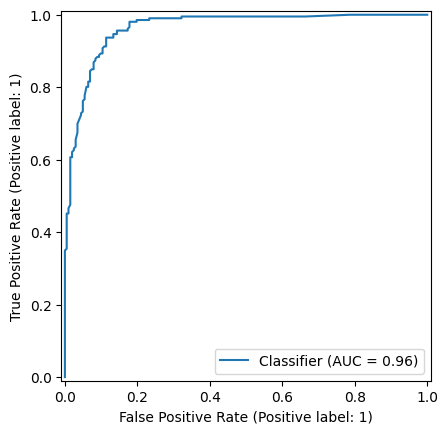

In [40]:
# AUC
auc = roc_auc_score(y_test, y_proba)
print("\nROC AUC:", auc)

# curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba)

#### o modelo possui ótima capacidade de separar bem as classes, com AUC de 96%,

#### na próxima etapa será validado, através da análise da Feature importance, se o modelo realmente capturou padrões reais ou se as variáveis comportamentais do dataset podem estar entregando o resultado quase pronto,

#### inflando parcialmete a performance do modelo.

#### Ainda assim, o modelo se mostra altamente eficaz como ferramenta de apoio à tomada de decisão em estratégias de marketing.

## **Feature importance**

#### nessa etapa será analisado se o modelo depende muito de comportamento passado (gastos dos clientes), indicando que as variáveis de histórico de compras podem introduzir viés preditivo, facilitando o trabalho do modelo.

#### O cenário ideal é que o modelo se apoie fortemente em variáveis de comportamento passado, comportamentos recentes, como número de visitas ao site e variáveis de perfil do cliente, como renda, pois isso indicará que o modelo é robusto e realista.

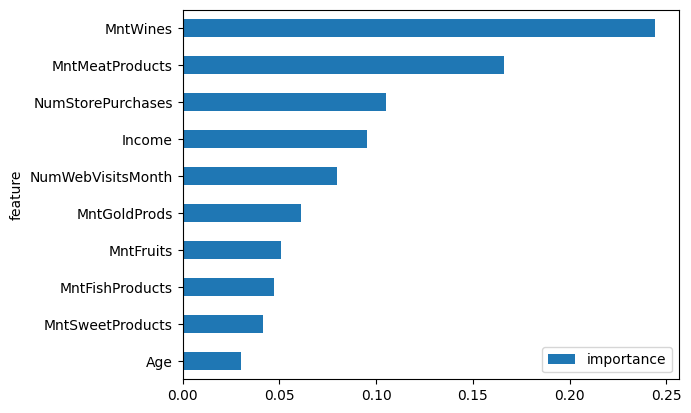

In [41]:
importances = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances,
}).sort_values(by='importance', ascending=False)

feature_importance.head(10).plot(
    x='feature',
    y='importance',
    kind='barh'
)

plt.gca().invert_yaxis()
plt.show()

#### O modelo apresenta forte dependência de comportamento passado, interpretando que quem já gastou muito tem alta probabilidade de comprar novamente.

#### clientes ativos na loja física também têm padrão forte de compradores no site.

#### o modelo se apoia 80% em comportamento passado e 20% em perfil + comportamentos recentes (engajamento), ou seja

#### o modelo mostra que o melhor preditor de compra futura é o comportamento passado, especialmente em categorias específicas como vinhos e carnes.

#### Isso sugere que estratégias de marketing devem focar em clientes já engajados, utilizando campanhas personalizadas baseadas no histórico de consumo,

#### por outro lado, o modelo pode ter menor capacidade de identificar novos clientes com potencial de compra, pois depende fortemente de comportamento anterior.

#### o modelo se mostra excelente no auxilio de estratégias de cross-sell e upsell, mas não tão bom para aquisição de novos clientes.

## **Conclusões finais**

#### O modelo desenvolvido demonstrou alta capacidade preditiva na identificação de clientes com maior probabilidade de compra, atingindo aproximadamente 90% de acurácia e AUC de 0.96 no conjunto de teste.

#### A comparação entre modelos mostrou que algoritmos mais robustos, como Random Forest, capturam melhor padrões não lineares presentes nos dados, superando o baseline de Regressão Logística.

#### Apesar do alto desempenho, foi identificado que o modelo depende fortemente de variáveis comportamentais diretamente relacionadas ao histórico de compra, o que pode facilitar a tarefa preditiva e inflar parcialmente os resultados.

#### Ainda assim, a consistência entre validação cruzada e teste final indica que o modelo possui boa capacidade de generalização, sendo adequado para aplicações reais de negócio, especialmente em estratégias de retenção e aumento de valor do cliente.

## **Próximos passos e possíveis melhorias**

#### - melhorar generalização do modelo, removendo variáveis diretamente relacionadas ao histórico de consumo (Mnt*), com o objetivo de avaliar a capacidade preditiva baseada apenas em perfil e comportamento de navegação.

#### - Aplicar técnicas como SHAP values para entender o impacto individual de cada variável nas previsões, permitindo maior transparência e explicabilidade do modelo.

#### - Ajustar o threshold de classificação com base no objetivo do negócio, priorizando métricas como recall ou precision conforme o custo de falsos positivos e falsos negativos.

#### - Integrar o modelo a estratégias de marketing para segmentação de clientes, permitindo campanhas direcionadas, aumento de conversão e redução de custos de aquisição.

#### Este projeto demonstra não apenas a construção de um modelo preditivo, mas também a preocupação com boas práticas de Machine Learning, como prevenção de vazamento de dados, validação robusta e interpretação dos resultados.

#### Além disso, a análise crítica sobre o comportamento do modelo e suas limitações reforça a importância de alinhar soluções de dados com o contexto de negócio.